# 01 — Exploratory Data Analysis
### AI4I 2020 Predictive Maintenance Dataset

**Owner:** Dev 1 · **Purpose:** establish the four facts that shape every downstream decision.

1. The class imbalance is severe enough that accuracy is a useless metric.
2. `Machine failure` is exactly the OR of the five mode flags — the leakage trap.
3. Each failure mode separates cleanly on one engineered feature. That is what makes the physics rules engine possible.
4. RNF is random noise and cannot be predicted.

Everything here uses `src/features.py`. Nothing is recomputed by hand, so the notebook and the trained model can never drift apart.

In [1]:
import sys, math
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from features import (build_feature_matrix, FEATURE_COLUMNS, MODE_COLUMNS,
                      OSF_LIMITS_MIN_NM, HDF_TEMP_DIFF_K, HDF_SPEED_RPM,
                      PWF_POWER_MIN_W, PWF_POWER_MAX_W, TWF_WEAR_MIN, TWF_WEAR_MAX)

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True,
                     "grid.alpha": .25, "font.size": 10})

X, y, df = build_feature_matrix()   # raises if the CSV is not the canonical file
print(f"{len(df):,} rows x {df.shape[1]} columns")
df.head()

10,000 rows x 20 columns


,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temp_diff_k,power_w,wear_torque_min_nm,osf_limit_min_nm,osf_margin,type_encoded
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,6951.590560,0.0,12000.0,0.000000,1
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,6826.722724,138.9,11000.0,0.012627,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,7749.387543,247.0,11000.0,0.022455,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,5927.504659,276.5,11000.0,0.025136,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,5897.816608,360.0,11000.0,0.032727,0


## 1. Class imbalance — why we never report accuracy

failures            339 / 10,000  (3.39%)
accuracy of a model that always predicts 'no failure': 96.61%

-> A useless model scores 96.6%. We lead with PR-AUC and recall instead.


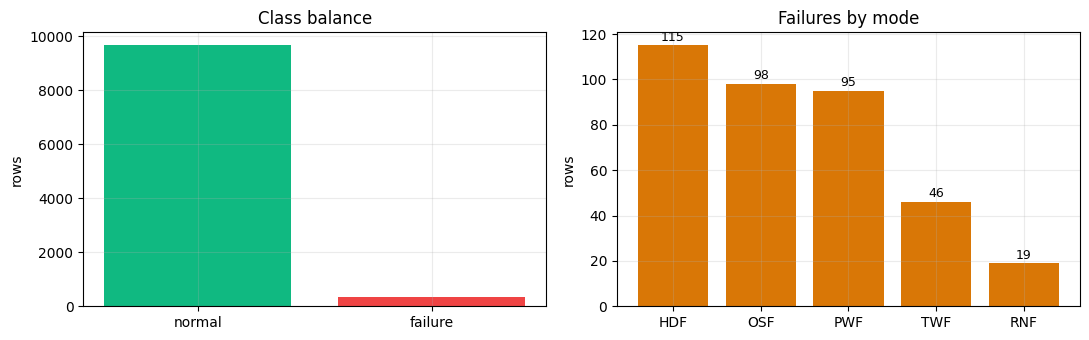

In [2]:
n, k = len(df), int(df["machine_failure"].sum())
print(f"failures            {k} / {n:,}  ({k/n:.2%})")
print(f"accuracy of a model that always predicts 'no failure': {1-k/n:.2%}")
print()
print("-> A useless model scores 96.6%. We lead with PR-AUC and recall instead.")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].bar(["normal", "failure"], [n-k, k], color=["#10B981", "#EF4444"])
ax[0].set_title("Class balance"); ax[0].set_ylabel("rows")
counts = df[MODE_COLUMNS].sum().sort_values(ascending=False)
ax[1].bar(counts.index.str.upper(), counts.values, color="#D97706")
for i, v in enumerate(counts.values):
    ax[1].text(i, v+2, str(int(v)), ha="center", fontsize=9)
ax[1].set_title("Failures by mode"); ax[1].set_ylabel("rows")
plt.tight_layout(); plt.show()

## 2. The leakage trap

`Machine failure = TWF OR HDF OR PWF OR OSF OR RNF`.

If this holds exactly, then feeding the mode flags into the model is feeding it the answer. Verify it rather than trusting the documentation.

In [3]:
or_of_modes = df[MODE_COLUMNS].max(axis=1)
agree = int((or_of_modes == df["machine_failure"]).sum())
print(f"rows where OR(modes) == machine_failure: {agree:,} / {len(df):,}")

flag_no_fail = df[(or_of_modes == 1) & (df.machine_failure == 0)]
fail_no_flag = df[(or_of_modes == 0) & (df.machine_failure == 1)]
print(f"  mode flag set but machine did not fail : {len(flag_no_fail)}")
print(f"  machine failed but NO mode flag set    : {len(fail_no_flag)}")
print()
print("Which modes appear in the 'flag but no failure' rows?")
print(flag_no_fail[MODE_COLUMNS].sum().astype(int).to_dict())

print("\nMode co-occurrence (how often two modes fire on the same row):")
display(df[MODE_COLUMNS].T.dot(df[MODE_COLUMNS]).astype(int))

rows where OR(modes) == machine_failure: 9,973 / 10,000
  mode flag set but machine did not fail : 18
  machine failed but NO mode flag set    : 9

Which modes appear in the 'flag but no failure' rows?
{'twf': 0, 'hdf': 0, 'pwf': 0, 'osf': 0, 'rnf': 18}

Mode co-occurrence (how often two modes fire on the same row):


,twf,hdf,pwf,osf,rnf
twf,46,0,1,3,1
hdf,0,115,3,6,0
pwf,1,3,95,12,0
osf,3,6,12,98,0
rnf,1,0,0,0,19


**Two things fall out of this, and the second one is not in the dataset documentation.**

1. The mode flags are effectively the target, so `src/features.py::assert_no_leakage()` blocks them from the feature matrix. Also dropped: `UDI` (row order) and `Product ID` (encodes `Type` plus a serial).

2. The identity is *not* exact. 18 rows carry an RNF flag that did not escalate to a machine failure, and — more importantly — **9 rows are labelled as machine failures with no mode flag at all.** Those 9 are unexplained by construction: no physical rule can account for them, because the dataset does not say what went wrong.

That sets a hard ceiling on the rules engine. The best any deterministic system can do is explain 330 of 339 failures. Stating that ceiling before a judge asks is worth more than pretending it does not exist.

## 3. Physical separation — the basis of the rules engine

The dataset was generated from documented physical conditions. If those conditions are real, each failure mode should sit in a visually obvious region of its own engineered feature. This is the evidence that the rules engine is not curve-fitting.

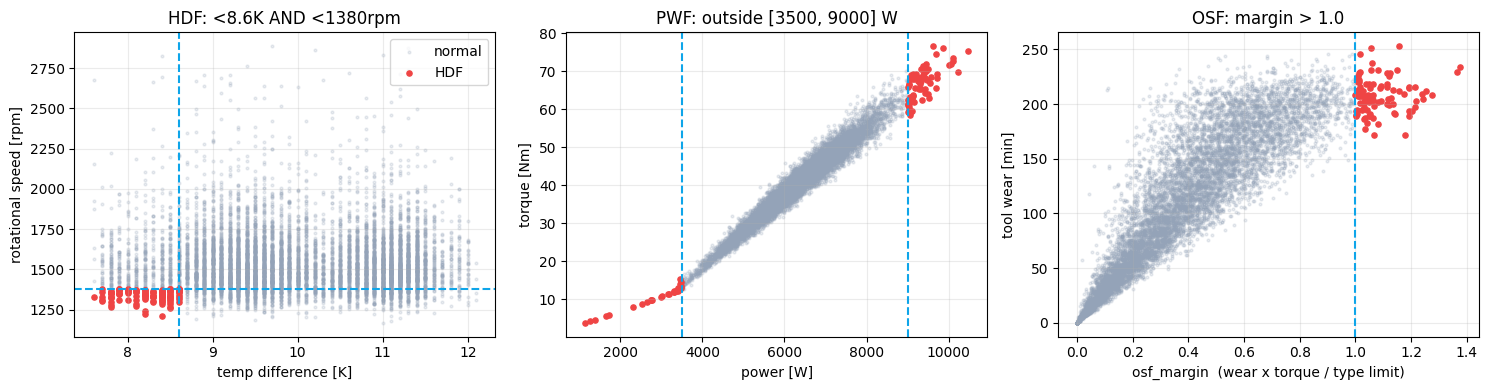

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# HDF: temp difference vs rotational speed
m = df["hdf"] == 1
axes[0].scatter(df.loc[~m, "temp_diff_k"], df.loc[~m, "rotational_speed_rpm"],
                s=4, alpha=.2, color="#94A3B8", label="normal")
axes[0].scatter(df.loc[m, "temp_diff_k"], df.loc[m, "rotational_speed_rpm"],
                s=14, color="#EF4444", label="HDF")
axes[0].axvline(HDF_TEMP_DIFF_K, ls="--", color="#0EA5E9")
axes[0].axhline(HDF_SPEED_RPM, ls="--", color="#0EA5E9")
axes[0].set_xlabel("temp difference [K]"); axes[0].set_ylabel("rotational speed [rpm]")
axes[0].set_title(f"HDF: <{HDF_TEMP_DIFF_K}K AND <{HDF_SPEED_RPM}rpm"); axes[0].legend()

# PWF: power band
m = df["pwf"] == 1
axes[1].scatter(df.loc[~m, "power_w"], df.loc[~m, "torque_nm"],
                s=4, alpha=.2, color="#94A3B8")
axes[1].scatter(df.loc[m, "power_w"], df.loc[m, "torque_nm"],
                s=14, color="#EF4444")
axes[1].axvline(PWF_POWER_MIN_W, ls="--", color="#0EA5E9")
axes[1].axvline(PWF_POWER_MAX_W, ls="--", color="#0EA5E9")
axes[1].set_xlabel("power [W]"); axes[1].set_ylabel("torque [Nm]")
axes[1].set_title(f"PWF: outside [{PWF_POWER_MIN_W}, {PWF_POWER_MAX_W}] W")

# OSF: normalised margin
m = df["osf"] == 1
axes[2].scatter(df.loc[~m, "osf_margin"], df.loc[~m, "tool_wear_min"],
                s=4, alpha=.2, color="#94A3B8")
axes[2].scatter(df.loc[m, "osf_margin"], df.loc[m, "tool_wear_min"],
                s=14, color="#EF4444")
axes[2].axvline(1.0, ls="--", color="#0EA5E9")
axes[2].set_xlabel("osf_margin  (wear x torque / type limit)"); axes[2].set_ylabel("tool wear [min]")
axes[2].set_title("OSF: margin > 1.0")
plt.tight_layout(); plt.show()

Each mode occupies exactly the region its documented rule predicts. `osf_margin` is the clearest of the three: dividing by the type-specific limit collapses the L/M/H thresholds onto a single line at 1.0, so one number covers all three product variants.

In [5]:
print("Threshold check straight from the data:\n")
hdf = df[df.hdf == 1]
print(f"HDF  max temp_diff among true HDF rows : {hdf.temp_diff_k.max():.2f} K   (rule: < {HDF_TEMP_DIFF_K})")
print(f"     max speed among true HDF rows     : {hdf.rotational_speed_rpm.max():.0f} rpm  (rule: < {HDF_SPEED_RPM})")
pwf = df[df.pwf == 1]
inside = ((pwf.power_w >= PWF_POWER_MIN_W) & (pwf.power_w <= PWF_POWER_MAX_W)).sum()
print(f"\nPWF  true PWF rows inside the safe power band: {inside} of {len(pwf)}  (expect 0)")
for t, lim in OSF_LIMITS_MIN_NM.items():
    s = df[(df.type == t) & (df.osf == 1)]
    if len(s):
        print(f"\nOSF  type {t}: {len(s)} failures, min wear x torque = {s.wear_torque_min_nm.min():,.0f} minNm (limit {lim:,})")

Threshold check straight from the data:

HDF  max temp_diff among true HDF rows : 8.60 K   (rule: < 8.6)
     max speed among true HDF rows     : 1379 rpm  (rule: < 1380)

PWF  true PWF rows inside the safe power band: 0 of 95  (expect 0)

OSF  type L: 87 failures, min wear x torque = 11,003 minNm (limit 11,000)

OSF  type M: 9 failures, min wear x torque = 12,337 minNm (limit 12,000)

OSF  type H: 2 failures, min wear x torque = 13,235 minNm (limit 13,000)


## 4. Tool wear and RNF — the two modes we are honest about

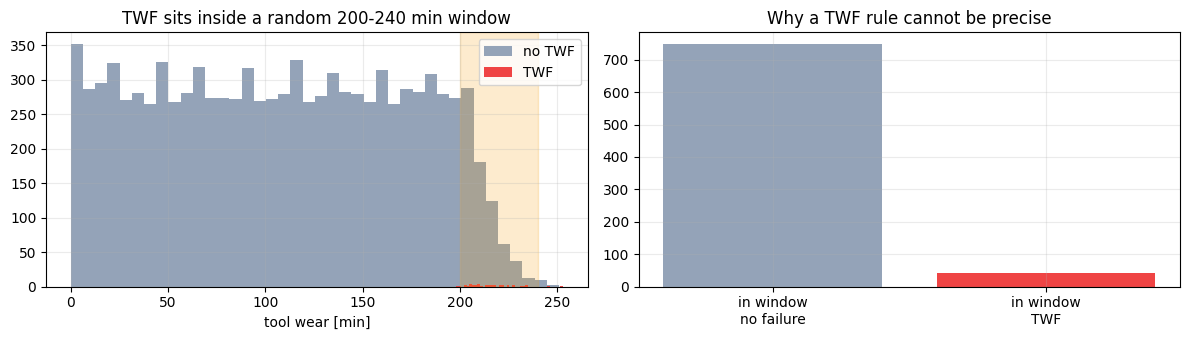

rows in the 200-240 min wear window : 790
of which actually failed (TWF)      : 43
-> best achievable precision for a deterministic TWF rule: 0.05

RNF rows: 19 (0.19%) - fires at random regardless of sensor
values, so it is excluded from the root-cause model by design.


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].hist(df.loc[df.twf == 0, "tool_wear_min"], bins=40, color="#94A3B8", label="no TWF")
ax[0].hist(df.loc[df.twf == 1, "tool_wear_min"], bins=40, color="#EF4444", label="TWF")
ax[0].axvspan(TWF_WEAR_MIN, TWF_WEAR_MAX, color="#F59E0B", alpha=.2)
ax[0].set_xlabel("tool wear [min]"); ax[0].set_title("TWF sits inside a random 200-240 min window")
ax[0].legend()

in_window = df[(df.tool_wear_min >= TWF_WEAR_MIN) & (df.tool_wear_min <= TWF_WEAR_MAX)]
ax[1].bar(["in window\nno failure", "in window\nTWF"],
          [len(in_window) - int(in_window.twf.sum()), int(in_window.twf.sum())],
          color=["#94A3B8", "#EF4444"])
ax[1].set_title("Why a TWF rule cannot be precise")
plt.tight_layout(); plt.show()

print(f"rows in the 200-240 min wear window : {len(in_window)}")
print(f"of which actually failed (TWF)      : {int(in_window.twf.sum())}")
print(f"-> best achievable precision for a deterministic TWF rule: {in_window.twf.mean():.2f}")
print()
rnf = df[df.rnf == 1]
print(f"RNF rows: {len(rnf)} ({len(rnf)/len(df):.2%}) - fires at random regardless of sensor")
print("values, so it is excluded from the root-cause model by design.")

**Two named limitations for the pitch:**

- A deterministic tool-wear rule tops out around 0.15 precision, because the failure point is drawn at random inside the 200–240 minute window. We report that number rather than tuning it away.
- RNF is a 0.1% coin flip with no sensor signature. It is not predictable by any model, and we say so on the limitations slide rather than letting a judge find it.

## 5. Feature correlations

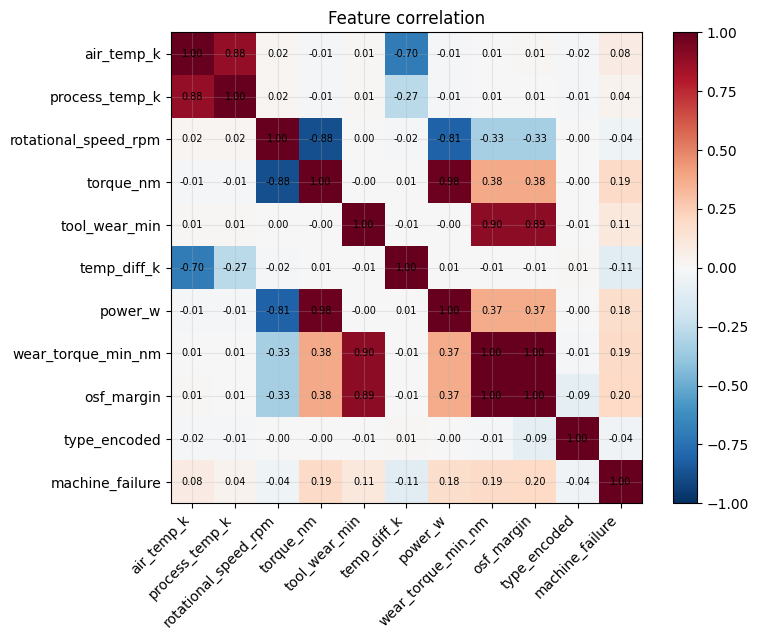

Correlation with machine_failure, strongest first:
osf_margin              0.195
torque_nm               0.191
wear_torque_min_nm      0.190
power_w                 0.176
temp_diff_k             0.112
tool_wear_min           0.105
air_temp_k              0.083
rotational_speed_rpm    0.044
type_encoded            0.037
process_temp_k          0.036
Name: machine_failure, dtype: float64


In [7]:
corr = df[FEATURE_COLUMNS + ["machine_failure"]].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, fraction=.046); plt.title("Feature correlation"); plt.tight_layout(); plt.show()

print("Correlation with machine_failure, strongest first:")
print(corr["machine_failure"].drop("machine_failure").abs().sort_values(ascending=False).round(3))

## 6. No time series

The dataset has no timestamps and no machine IDs. Rows are independent snapshots, not a sequence. We use `UDI` purely as a replay index so the demo can stream rows at ~2/sec and look live.

We state this openly in the pitch. Claiming a time-series capability the data cannot support is the fastest way to lose a technical judge.

In [8]:
print("columns:", list(df.columns))
print("\nno timestamp column, no machine id column -> confirmed")
print("\nUDI is a dense 1..N index:",
      bool((df.udi.values == np.arange(1, len(df)+1)).all()))

columns: ['udi', 'product_id', 'type', 'air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf', 'temp_diff_k', 'power_w', 'wear_torque_min_nm', 'osf_limit_min_nm', 'osf_margin', 'type_encoded']

no timestamp column, no machine id column -> confirmed

UDI is a dense 1..N index: True


## Summary — what this notebook establishes

| Finding | Consequence |
|---|---|
| 3.39% positive rate | Report PR-AUC and recall, never accuracy |
| `machine_failure` = OR of 5 mode flags | Mode flags, `UDI`, `Product ID` dropped from features |
| HDF / PWF / OSF separate exactly on their documented thresholds | `rules_engine.py` can verify causes deterministically |
| TWF failure point is random in a 200-240 min window | Tool-wear rule is a risk window; ~0.15 precision is honest, not broken |
| RNF is a 0.1% coin flip | Excluded from the root-cause model; goes on the limitations slide |
| No timestamps, no machine IDs | `UDI` used as a replay index only; stated openly in the demo |

Next: `python src/train.py`